In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import shap

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score

from xgboost import XGBRegressor

ROOT = Path.cwd().parents[1]
print(ROOT)

DATA_RAW = ROOT/"data/raw"
DATA_PROCESSED = ROOT/"data/processed"

c:\Users\sebas\PycharmProjects\Git\BoxOffice_Oracle


In [13]:
model_df = pd.read_csv(
    DATA_RAW/"fe_groups/g2.csv"
)

print(model_df.shape)
model_df.head()

(2255, 86)


,Unnamed: 0.1,Unnamed: 0,tconst,primaryTitle,startYear,the_numbers_url,scrape_success,scrape_error,opening_weekend_gross,opening_theaters,...,g2_revenue_acceleration_distributor,g2_rolling3_growth_rate_distributor,g2_prev_gross_genre,g2_rolling3_avg_gross_genre,g2_revenue_velocity_genre,g2_revenue_acceleration_genre,g2_rolling3_growth_rate_genre,g2_top3_actor_rolling3_avg_gross_mean,g2_top3_actor_rolling3_avg_gross_max,g2_top3_actor_rolling3_avg_gross_total
0,0,1112,tt1311067,Halloween II,2009.0,https://www.the-numbers.com/movie/Halloween-II,True,NaN,7676836.0,1217.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
1,1,689,tt0816462,Conan the Barbarian,2011.0,https://www.the-numbers.com/movie/Conan-the-Ba...,True,NaN,9479373.0,1358.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2,2,1974,tt4731008,The Wild Life,2016.0,https://www.the-numbers.com/movie/Wild-Life-The,True,NaN,4001400.0,1140.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
3,3,980,tt1160419,Dune: Part One,2021.0,https://www.the-numbers.com/movie/Dune,True,NaN,6025091.0,915.0,...,NaN,0.234802,9479373.0,9479373.0,NaN,NaN,NaN,NaN,NaN,0.0
4,4,1291,tt1540128,Playing for Keeps,2012.0,https://www.the-numbers.com/movie/Playing-for-...,True,NaN,1406300.0,1148.0,...,-2628409.5,-0.064799,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0


In [14]:
target = "log_opening_weekend_gross"

g2_features = [
    'g2_prev_gross_director',
    'g2_rolling3_avg_gross_director',
    'g2_revenue_velocity_director',
    'g2_revenue_acceleration_director',
    'g2_rolling3_growth_rate_director',
    'g2_prev_gross_writer',
    'g2_rolling3_avg_gross_writer',
    'g2_revenue_velocity_writer',
    'g2_revenue_acceleration_writer',
    'g2_rolling3_growth_rate_writer',
    'g2_prev_gross_actor_1',
    'g2_rolling3_avg_gross_actor_1',
    'g2_revenue_velocity_actor_1',
    'g2_revenue_acceleration_actor_1',
    'g2_rolling3_growth_rate_actor_1',
    'g2_prev_gross_actor_2',
    'g2_rolling3_avg_gross_actor_2',
    'g2_revenue_velocity_actor_2',
    'g2_revenue_acceleration_actor_2',
    'g2_rolling3_growth_rate_actor_2',
    'g2_prev_gross_actor_3',
    'g2_rolling3_avg_gross_actor_3',
    'g2_revenue_velocity_actor_3',
    'g2_revenue_acceleration_actor_3',
    'g2_rolling3_growth_rate_actor_3',
    'g2_prev_gross_distributor',
    'g2_rolling3_avg_gross_distributor',
    'g2_revenue_velocity_distributor',
    'g2_revenue_acceleration_distributor',
    'g2_rolling3_growth_rate_distributor',
    'g2_prev_gross_genre',
    'g2_rolling3_avg_gross_genre',
    'g2_revenue_velocity_genre',
    'g2_revenue_acceleration_genre',
    'g2_rolling3_growth_rate_genre',
    'g2_top3_actor_rolling3_avg_gross_mean',
    'g2_top3_actor_rolling3_avg_gross_max',
    'g2_top3_actor_rolling3_avg_gross_total'
]

numeric_features = [
    # "opening_theaters",
    "production_budget",
    "runtime_minutes",
    "release_month",
    "release_day_of_year",
] + g2_features

people_features = [
    "director_id",
    "writer_id",
    "actor_1",
    "actor_2",
    "actor_3",
]

categorical_features = [
    # "release_type",
    "distributor",
    "MPA_rating",
    "genre",
    "subgenre",
    "source",
    "production_method",
    "creative_type",
    "production_countries",
    "languages",
] + people_features

In [15]:
feature_cols = numeric_features + categorical_features

model_data = model_df[
    feature_cols + [target, "opening_weekend_gross"]
].copy()

X = model_data[feature_cols]
y = model_data[target]

print(X.shape)
print(y.shape)

(2255, 56)
(2255,)


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [17]:
y_test_dollars = np.expm1(y_test)

In [18]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [19]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)

    pred_log = model.predict(X_test)

    r2_log = r2_score(y_test, pred_log)
    mae_log = mean_absolute_error(y_test, pred_log)

    pred_dollars = np.expm1(pred_log)

    mae_dollars = mean_absolute_error(y_test_dollars, pred_dollars)

    results = {
        "model": name,
        "r2_log": r2_log,
        "mae_log": mae_log,
        "mae_dollars": mae_dollars
    }

    return results, pred_log, pred_dollars

In [20]:
ridge_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

ridge_results, ridge_pred_log, ridge_pred_dollars = evaluate_model(
    "Ridge Baseline",
    ridge_model,
    X_train,
    X_test,
    y_train,
    y_test
)

ridge_results

{'model': 'Ridge Baseline',
 'r2_log': 0.5879715523815152,
 'mae_log': 0.8070012697399342,
 'mae_dollars': 13868388.825594101}

In [21]:
xgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42
    ))
])

xgb_results, xgb_pred_log, xgb_pred_dollars = evaluate_model(
    "XGBoost Baseline",
    xgb_model,
    X_train,
    X_test,
    y_train,
    y_test
)

xgb_results

{'model': 'XGBoost Baseline',
 'r2_log': 0.6253534622222725,
 'mae_log': 0.7509391015086634,
 'mae_dollars': 11862009.181541016}

In [22]:
results_df = pd.DataFrame([
    ridge_results,
    xgb_results
])

results_df

,model,r2_log,mae_log,mae_dollars
0,Ridge Baseline,0.587972,0.807001,1.386839e+07
1,XGBoost Baseline,0.625353,0.750939,1.186201e+07


In [23]:
plot_df = pd.DataFrame({
    "actual": y_test_dollars,
    "predicted": xgb_pred_dollars
})

fig = px.scatter(
    plot_df,
    x="actual",
    y="predicted",
    title="XGBoost Baseline: Actual vs Predicted",
    opacity=0.6
)

fig.add_shape(
    type="line",
    x0=plot_df["actual"].min(),
    y0=plot_df["actual"].min(),
    x1=plot_df["actual"].max(),
    y1=plot_df["actual"].max(),
)

fig.show()

In [24]:
X_train_transformed = (
    xgb_model.named_steps["preprocessor"]
    .transform(X_train)
)

X_test_transformed = (
    xgb_model.named_steps["preprocessor"]
    .transform(X_test)
)

feature_names = (
    xgb_model.named_steps["preprocessor"]
    .get_feature_names_out()
)

trained_xgb = xgb_model.named_steps["model"]

In [25]:
explainer = shap.TreeExplainer(trained_xgb)

X_shap = X_test_transformed[:500]

shap_values = explainer.shap_values(X_shap)

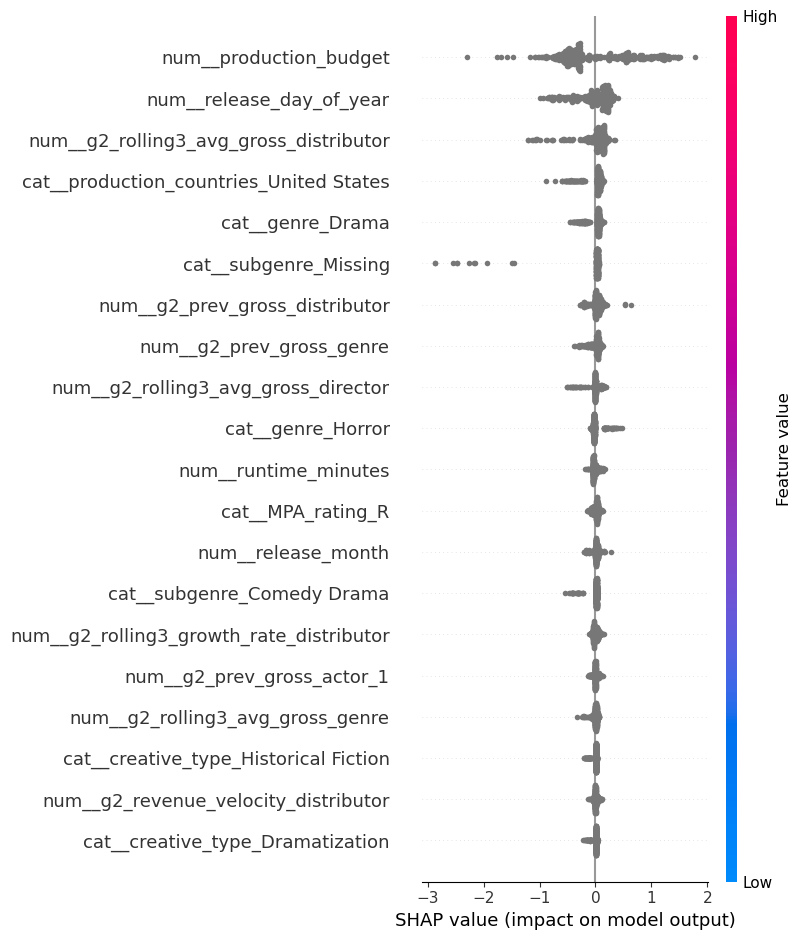

In [26]:
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names
)

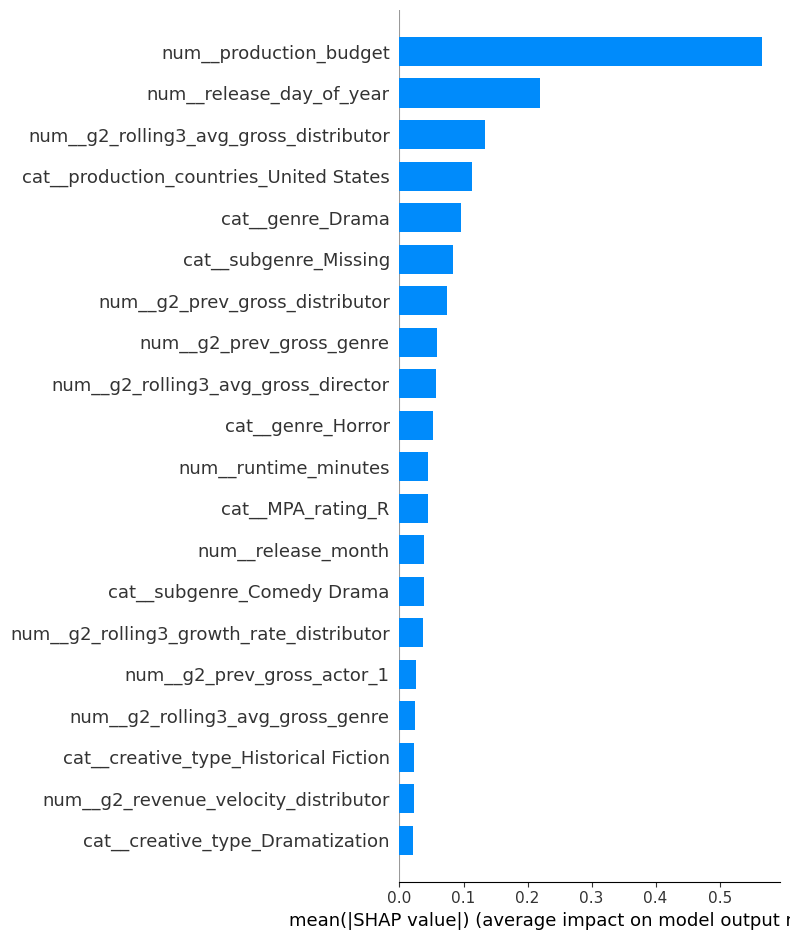

In [27]:
shap.summary_plot(
    shap_values,
    X_shap,
    feature_names=feature_names,
    plot_type="bar"
)

In [28]:
error_df = X_test.copy()

error_df["actual_log"] = y_test
error_df["pred_log"] = xgb_pred_log

error_df["actual_opening_weekend"] = np.expm1(y_test)
error_df["pred_opening_weekend"] = xgb_pred_dollars

error_df["abs_error"] = (
    error_df["actual_opening_weekend"] -
    error_df["pred_opening_weekend"]
).abs()

error_df.sort_values("abs_error", ascending=False).head(20)

,production_budget,runtime_minutes,release_month,release_day_of_year,g2_prev_gross_director,g2_rolling3_avg_gross_director,g2_revenue_velocity_director,g2_revenue_acceleration_director,g2_rolling3_growth_rate_director,g2_prev_gross_writer,...,director_id,writer_id,actor_1,actor_2,actor_3,actual_log,pred_log,actual_opening_weekend,pred_opening_weekend,abs_error
1847,400000000.0,181.0,4,116,179139142.0,9.856281e+07,7.880679e+07,5.308630e+06,2.149832,179139142.0,...,nm0751577,nm1321655,nm0000375,nm0262635,nm0749263,19.693568,19.038944,3.571150e+08,1.855703e+08,1.715447e+08
2126,145000000.0,114.0,7,202,16755310.0,8.559874e+06,1.639087e+07,NaN,44.975875,16755310.0,...,nm1950086,nm1950086,nm3053338,nm0331516,nm4793987,18.903243,17.330660,1.620220e+08,3.362095e+07,1.284011e+08
1907,150000000.0,103.0,11,326,243390.0,2.433900e+05,NaN,NaN,NaN,33123609.0,...,nm0118333,nm1601644,nm0068338,nm0579953,nm1265802,18.685069,14.914000,1.302634e+08,2.999629e+06,1.272637e+08
1619,160000000.0,123.0,3,76,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,nm5177626,nm11380870,nm3592451,18.978870,17.730387,1.747506e+08,5.014286e+07,1.246078e+08
1620,160000000.0,123.0,3,76,2434908.0,9.387493e+07,6.853193e+05,-4.628088e+07,120.841785,228359.0,...,nm0174374,nm0154716,nm0914612,nm1405398,nm1812656,18.978870,17.827955,1.747506e+08,5.528185e+07,1.194688e+08
1718,200000000.0,120.0,2,47,29632823.0,2.963282e+07,NaN,NaN,NaN,29632823.0,...,nm3363032,nm3363032,nm1569276,nm0430107,nm2143282,19.123798,18.275019,2.020040e+08,8.644498e+07,1.155590e+08
1942,205000000.0,110.0,9,247,50513488.0,8.630371e+07,-4.090616e+06,3.287642e+07,0.307003,50513488.0,...,nm0634240,nm0634240,nm0913475,nm1500155,nm4456120,16.811335,18.526497,2.000185e+07,1.111617e+08,9.115989e+07
2204,200000000.0,100.0,6,166,NaN,NaN,NaN,NaN,NaN,39155217.0,...,nm1626375,nm0498834,nm0688132,nm1638321,nm10143485,18.853772,17.975544,1.542017e+08,6.407366e+07,9.012801e+07
2246,145000000.0,160.0,11,327,11504710.0,2.013267e+07,-9.665701e+06,-8.664397e+06,-0.276334,NaN,...,nm0160840,nm0392848,nm7248827,nm3812858,nm0000156,18.538543,17.136465,1.125089e+08,2.768676e+07,8.482213e+07
1832,175000000.0,124.0,3,67,NaN,NaN,NaN,NaN,NaN,NaN,...,nm1349818,nm1349818,nm0488953,nm0000168,nm0578853,18.848777,18.117363,1.534334e+08,7.383644e+07,7.959698e+07


In [31]:
results_df.to_csv(
    DATA_PROCESSED/"feature_testing/g2_model_results.csv",
    index=False
)

error_df.to_csv(
    DATA_PROCESSED/"feature_testing/g2_xgb_test_errors.csv",
    index=False
)